<a href="https://colab.research.google.com/github/pranatixsharma/fintech-system/blob/main/customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/fintech/customer_summary.csv')

print(df.shape)
print(df.isnull().sum())

(2000, 13)
client_id              0
current_age            0
yearly_income          0
total_debt             0
credit_score           0
txn_count              0
total_spend          781
avg_txn_amount       781
unique_merchants       0
last_txn_date        781
labeled_txn_count      0
fraud_count            0
fraud_rate_pct       781
dtype: int64


###minimal preprocessing

In [8]:
#Drop customers with no transactions
df = df[df['txn_count'] > 0]
#Handle nulls in credit_score
df['credit_score'] = df['credit_score'].replace(0, df['credit_score'].median())

In [9]:
#Handle skewed features
import numpy as np
df['total_spend_log'] = np.log1p(df['total_spend'])

###feature selection


In [10]:
features = [
    'txn_count',
    'total_spend',
    'avg_txn_amount',
    'unique_merchants',
    'credit_score',
    'fraud_rate_pct'
]

X = df[features].fillna(0)

###scaling

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

###Elbow method


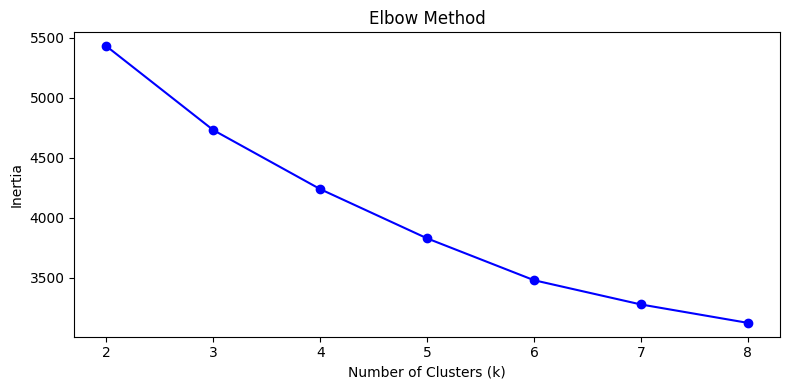

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(2, 9)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fintech/reports/elbow_plot.png')
plt.show()

K= 4

###Clustering + Interpretation

In [14]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X_scaled)

In [15]:
profile = df.groupby('cluster')[features].mean().round(2)
print(profile)

         txn_count  total_spend  avg_txn_amount  unique_merchants  \
cluster                                                             
0          6073.64    287695.71           48.80            243.38   
1          9574.20    301255.21           32.65            245.47   
2         21341.76    952834.99           46.15            398.44   
3         10726.85    608156.06           58.49            347.57   

         credit_score  fraud_rate_pct  
cluster                                
0              709.56            0.52  
1              721.16            0.14  
2              709.78            0.09  
3              703.89            0.13  


In [16]:
cluster_labels = {
    0: 'Dormant',
    1: 'Casual',
    2: 'Power Users',
    3: 'Premium'
}

df['segment'] = df['cluster'].map(cluster_labels)

####policy recommendation

*   DormantRe-engagement campaign — offer cashback on first transaction
*   Casual-Upsell to premium card — target with rewards program
*   Power users- Retain with loyalty points — monitor for churn signals
*   Premium-Priority customer service — fraud monitoring priority






In [17]:
df[['client_id', 'cluster', 'segment'] + features].to_csv(
    '/content/drive/MyDrive/fintech/processed/customer_segments.csv', index=False
)